<a href="https://colab.research.google.com/github/adljna/Blu-SentimentAnalysis/blob/main/Week%204/TF-IDF/1C-TFIDF-DetikNews.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **(1) Import Dependencies**
This section initializes all necessary Python libraries for text processing, TF-IDF calculation, and visualization.

In [10]:
!pip install Sastrawi

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 209.7/209.7 kB 6.6 MB/s eta 0:00:00


In [11]:
import nltk
from nltk.tokenize import sent_tokenize
from nltk.corpus import stopwords
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory
from sklearn.feature_extraction.text import TfidfVectorizer
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


# **(2) Define Document**
This section defines the input document (news article) that will be processed for TF-IDF based summarization.

In [12]:
detik = """Presiden Amerika Serikat (AS) Donald Trump mengatakan bahwa perang melawan Iran saat ini sudah "sangat tuntas". Trump menyebut Washington jauh lebih cepat dari perkiraan awal soal perang akan berlangsung selama empat hingga lima pekan.
Pernyataan terbaru Trump itu, seperti dilansir Reuters, Selasa (10/3/2026), disampaikan dalam wawancara telepon dengan CBS News pada Senin (9/3) sore waktu setempat. AS dan Israel melancarkan serangan skala besar terhadap Iran sejak 28 Februari lalu, yang memicu eskalasi konflik di kawasan Timur Tengah.

"Saya pikir perang ini sudah sangat tuntas, hampir sepenuhnya," kata Trump, berbicara kepada CBS News dalam wawancara telepon dari klub golfnya di Doral, Florida.

"Mereka (Iran-red) tidak memiliki angkatan laut, tidak ada komunikasi, mereka tidak memiliki angkatan udara. Rudal-rudal mereka tinggal sedikit. Drone-drone mereka dihancurkan di mana-mana, termasuk pabrik pembuatan drone mereka," klaim Trump dalam wawancara tersebut.

Militer AS sebelumnya mengatakan pasukannya telah menyerang lebih dari 3.000 target di wilayah Iran pada minggu pertama operasi militer, yang diberi nama "Operation Epic Fury" ini.

"Jika Anda lihat, mereka tidak memiliki apa pun yang tersisa. Tidak ada yang tersisa dalam artian militernya," ucap Trump saat berbicara kepada wartawan CBS News, Weijia Jiang, dalam wawancara telepon itu.

Lebih lanjut, Trump juga menyebut bahwa AS "sangat jauh" melebihi perkiraan awal untuk durasi perang, yang sebelumnya diperkirakan oleh Trump sendiri akan berlangsung selama 4-5 minggu.

"Kita sangat jauh lebih cepat dari jadwal," sebutnya.

Ketika ditanya apakah menurutnya perang akan segera berakhir, Trump menjawab: "Berakhirnya perang itu hanya ada di pikiran saya, bukan pikiran orang lain."

Sementara itu mengenai pemimpin tertinggi baru Iran, Mojtaba Khamenei, yang menggantikan mendiang ayahnya, Ayatollah Ali Khamenei, Trump enggan berkomentar banyak.

"Saya tidak punya pesan untuknya. Sama sekali tidak," ujar Trump, sembari menambahkan bahwa dirinya memiliki orang lain dalam pikirannya untuk menggantikan Khamenei, tetapi dia tidak menjelaskan lebih lanjut.

Trump sebelumnya dilaporkan "tidak senang" dengan pemilihan Mojtaba sebagai pemimpin tertinggi baru Iran.
"""

# **(3) Text Preprocessing**
This section covers the initial steps to clean and prepare the text, making it suitable for TF-IDF analysis. It involves breaking the text into sentences and removing common, less informative words.

### Sentence Tokenization

This step breaks down the large block of text into individual sentences. This is crucial for summarization, as TF-IDF scores will be calculated per sentence, and sentences with higher scores will be selected for the summary.

In [13]:
# Sentence tokenization
sentence = sent_tokenize(detik)
print("Tokenized sentences:")
for sent in sentence:
    print(sent)

Tokenized sentences:
Presiden Amerika Serikat (AS) Donald Trump mengatakan bahwa perang melawan Iran saat ini sudah "sangat tuntas".
Trump menyebut Washington jauh lebih cepat dari perkiraan awal soal perang akan berlangsung selama empat hingga lima pekan.
Pernyataan terbaru Trump itu, seperti dilansir Reuters, Selasa (10/3/2026), disampaikan dalam wawancara telepon dengan CBS News pada Senin (9/3) sore waktu setempat.
AS dan Israel melancarkan serangan skala besar terhadap Iran sejak 28 Februari lalu, yang memicu eskalasi konflik di kawasan Timur Tengah.
"Saya pikir perang ini sudah sangat tuntas, hampir sepenuhnya," kata Trump, berbicara kepada CBS News dalam wawancara telepon dari klub golfnya di Doral, Florida.
"Mereka (Iran-red) tidak memiliki angkatan laut, tidak ada komunikasi, mereka tidak memiliki angkatan udara.
Rudal-rudal mereka tinggal sedikit.
Drone-drone mereka dihancurkan di mana-mana, termasuk pabrik pembuatan drone mereka," klaim Trump dalam wawancara tersebut.
Milite

### Stop Word Removal

Stop words are common words (like 'yang', 'dan', 'ini' in Indonesian) that don't carry much meaning and can skew TF-IDF scores. This step removes them to focus on more significant terms.

In [14]:
# Initialize Indonesian StopWordRemover
factory = StopWordRemoverFactory()
stopword_remover = factory.create_stop_word_remover()

# Remove stop words from each sentence
cleaned_sentences = [stopword_remover.remove(sent) for sent in sentence]
print("\nCleaned sentences (Indonesian stop words removed):")
for clean_sent in cleaned_sentences:
    print(clean_sent)


Cleaned sentences (Indonesian stop words removed):
Presiden Amerika Serikat (AS) Donald Trump mengatakan perang melawan Iran ini "sangat tuntas".
Trump menyebut Washington jauh lebih cepat perkiraan awal soal perang berlangsung selama empat hingga lima pekan.
Pernyataan terbaru Trump itu, dilansir Reuters, Selasa (10/3/2026), disampaikan wawancara telepon CBS News Senin (9/3) sore waktu setempat.
AS Israel melancarkan serangan skala besar Iran sejak 28 Februari lalu, memicu eskalasi konflik kawasan Timur Tengah.
"Saya pikir perang sudah sangat tuntas, hampir sepenuhnya," kata Trump, berbicara CBS News wawancara telepon klub golfnya Doral, Florida.
"Mereka (Iran-red) memiliki angkatan laut, ada komunikasi, tidak memiliki angkatan udara.
Rudal-rudal tinggal sedikit.
Drone-drone dihancurkan mana-mana, termasuk pabrik pembuatan drone mereka," klaim Trump wawancara tersebut.
Militer AS sebelumnya mengatakan pasukannya menyerang lebih 3.000 target wilayah Iran minggu pertama operasi militer

# **(4) Scikit-learn TF-IDF Vectorization**

This section uses the `TfidfVectorizer` from scikit-learn to efficiently compute the TF-IDF scores for all words across all cleaned sentences. This vectorized representation is then used for the summarization process.

In [15]:
# Training TF-IDF Vectorizer on the cleaned sentences
vectorizer = TfidfVectorizer()
features = vectorizer.fit_transform(cleaned_sentences)
feature_names = vectorizer.get_feature_names_out()

In [16]:
print("\nTF-IDF Feature Matrix (Sparse) on Cleaned Sentences:")
print(features)
print("\nShape of the Feature Matrix (Number of sentences, Number of unique words):")
print(features.shape)

# To see the feature names (the words in the vocabulary after Indonesian stop word removal):
feature_names = vectorizer.get_feature_names_out()
print("\nFeature Names (Words in the vocabulary):")
print(feature_names)


TF-IDF Feature Matrix (Sparse) on Cleaned Sentences:
<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 242 stored elements and shape (18, 169)>
  Coords	Values
  (0, 116)	0.3270753086350138
  (0, 6)	0.3270753086350138
  (0, 139)	0.3270753086350138
  (0, 11)	0.2348977704467798
  (0, 37)	0.3270753086350138
  (0, 156)	0.14682686657003158
  (0, 84)	0.28628609819501355
  (0, 108)	0.21655648238252256
  (0, 78)	0.3270753086350138
  (0, 53)	0.20104914428312246
  (0, 52)	0.28628609819501355
  (0, 122)	0.2348977704467798
  (0, 157)	0.28628609819501355
  (1, 156)	0.12802907085686496
  (1, 108)	0.1888314167233232
  (1, 90)	0.24963376258978148
  (1, 164)	0.2852008548775376
  (1, 57)	0.2243985090110793
  (1, 73)	0.1888314167233232
  (1, 25)	0.24963376258978148
  (1, 109)	0.24963376258978148
  (1, 12)	0.24963376258978148
  (1, 142)	0.2852008548775376
  (1, 21)	0.24963376258978148
  (1, 130)	0.24963376258978148
  :	:
  (16, 71)	0.22781468351785286
  (16, 101)	0.22781468351785286
  (16, 63

# **(5) TF-IDF Based Summarization**

This section calculates the average TF-IDF score for each sentence and identifies sentences that are most representative of the document based on a calculated threshold. These sentences then form the summary.

In [17]:
# To see the TF-IDF values for a specific cleaned sentence (e.g., the first):
if cleaned_sentences:
    first_cleaned_sentence_tfidf = features[0].toarray()
    print("\nTF-IDF values for the first sentence:")
    print(first_cleaned_sentence_tfidf)

    def get_tfidf_for_sentence(tfidf_matrix, sentence_index, feature_names):
        """Returns a DataFrame of TF-IDF values for a given sentence."""
        sentence_tfidf_values = tfidf_matrix[sentence_index].toarray().flatten()
        tfidf_df = pd.DataFrame({'Feature': feature_names, 'TF-IDF': sentence_tfidf_values})
        tfidf_df = tfidf_df[tfidf_df['TF-IDF'] > 0].sort_values(by='TF-IDF', ascending=False)
        return tfidf_df

    first_cleaned_sentence_tfidf_df = get_tfidf_for_sentence(features, 0, feature_names)
    print("\nTF-IDF values for the first cleaned sentence (sorted):")
    print(first_cleaned_sentence_tfidf_df)
else:
    print("\nNo cleaned sentences to process.")


TF-IDF values for the first sentence:
[[0.         0.         0.         0.         0.         0.
  0.32707531 0.         0.         0.         0.         0.23489777
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.32707531 0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.2862861  0.20104914
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.32707531 0.         0.         0.         0.         0.
  0.2862861  0.         0.         0.         0.         0.
  0.         0.         0.         0.        

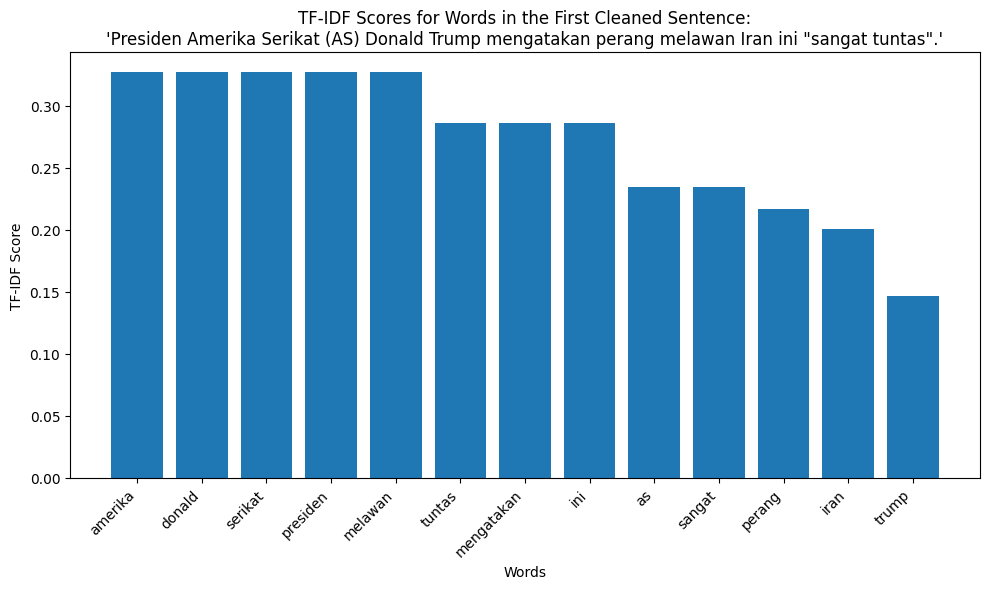

In [18]:
# Get TF-IDF scores for the first sentence
if cleaned_sentences:
    first_cleaned_sentence = cleaned_sentences[0]
    first_sentence_tfidf_df = get_tfidf_for_sentence(features, 0, feature_names)

    # Visualize the TF-IDF scores as a histogram
    plt.figure(figsize=(10, 6))
    plt.bar(first_sentence_tfidf_df['Feature'], first_sentence_tfidf_df['TF-IDF'])
    plt.xlabel("Words")
    plt.ylabel("TF-IDF Score")
    plt.title(f"TF-IDF Scores for Words in the First Cleaned Sentence:\n'{first_cleaned_sentence}'")
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()
else:
    print("No cleaned sentences to visualize.")

### TF-IDF Score for 'world' in Each Sentence


TF-IDF Scores for 'amerika' in each sentence::


,Sentence Number,TF-IDF Score (amerika)
0,1,0.327075
1,2,0.000000
2,3,0.000000
3,4,0.000000
4,5,0.000000
5,6,0.000000
6,7,0.000000
7,8,0.000000
8,9,0.000000
9,10,0.000000


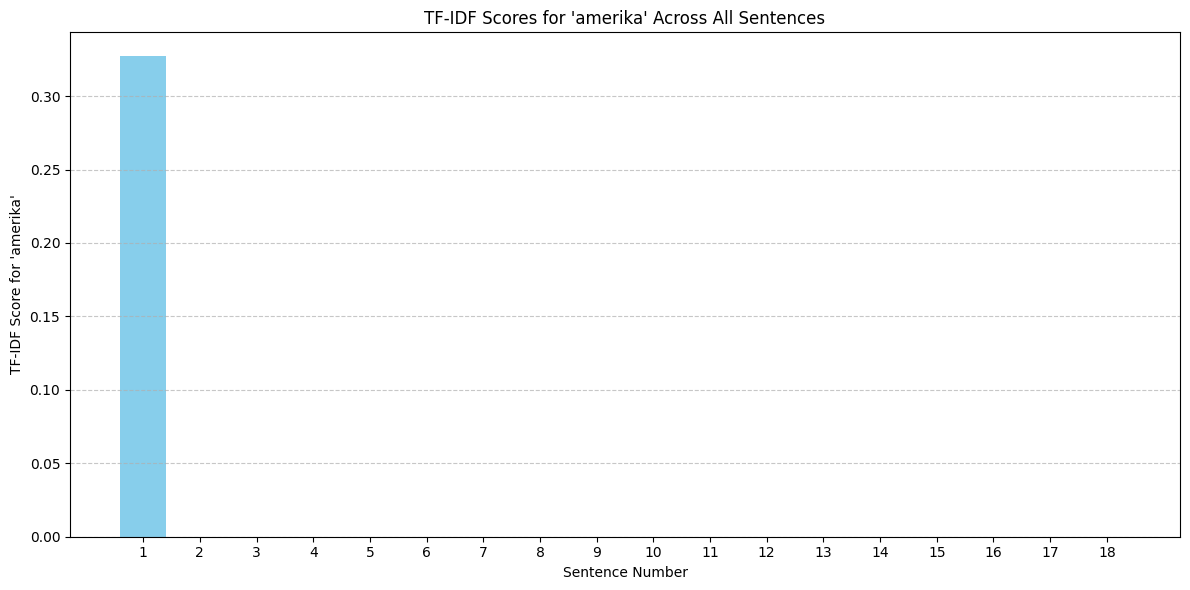

In [19]:
amerika_index = list(feature_names).index('amerika')
amerika_tfidf_scores = []
for i, _ in enumerate(sentence):
    score = features[i, amerika_index] # Get TF-IDF score for 'amerika' in sentence i
    amerika_tfidf_scores.append(score)

amerika_df = pd.DataFrame({
    'Sentence Number': range(1, len(sentence) + 1),
    'TF-IDF Score (amerika)': amerika_tfidf_scores
})
print("\nTF-IDF Scores for 'amerika' in each sentence::")
display(amerika_df)

# Visualize the TF-IDF scores for 'amerika' in each sentence
plt.figure(figsize=(12, 6))
plt.bar(amerika_df['Sentence Number'], amerika_df['TF-IDF Score (amerika)'], color='skyblue')
plt.xlabel("Sentence Number")
plt.ylabel("TF-IDF Score for 'amerika'")
plt.title("TF-IDF Scores for 'amerika' Across All Sentences")
plt.xticks(range(1, len(sentence) + 1))
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### TF-IDF Score for Each Sentence

In [20]:
# Variable initialization
sent_index = 0
sent_scores = []

# Calculate average TF-IDF score for each sentence with detailed output
print("\n**Calculating Average TF-IDF Score for Each Sentence:**")
for i in features:
    print(f"- Sentence {sent_index + 1}")
    sent_score = i.sum()
    sent_length = len(i.data)
    print(f"  Sum of TF-IDF scores: {sent_score:.4f}")
    print(f"  Number of words: {sent_length}")
    avg_score = sent_score / sent_length if sent_length > 0 else 0
    print(f"  Average TF-IDF score: {avg_score:.4f}")
    sent_scores.append(avg_score)
    sent_index += 1
print("\n-------------------------")

# Calculate the average of all sentence scores (threshold)
threshold = sum(sent_scores) / len(sent_scores) if sent_scores else 0

print(f"\nThreshold (Average of all Sentence Scores): {threshold:.4f}")


**Calculating Average TF-IDF Score for Each Sentence:**
- Sentence 1
  Sum of TF-IDF scores: 3.5285
  Number of words: 13
  Average TF-IDF score: 0.2714
- Sentence 2
  Sum of TF-IDF scores: 3.9391
  Number of words: 16
  Average TF-IDF score: 0.2462
- Sentence 3
  Sum of TF-IDF scores: 4.1879
  Number of words: 18
  Average TF-IDF score: 0.2327
- Sentence 4
  Sum of TF-IDF scores: 4.0969
  Number of words: 17
  Average TF-IDF score: 0.2410
- Sentence 5
  Sum of TF-IDF scores: 4.2922
  Number of words: 19
  Average TF-IDF score: 0.2259
- Sentence 6
  Sum of TF-IDF scores: 2.9681
  Number of words: 10
  Average TF-IDF score: 0.2968
- Sentence 7
  Sum of TF-IDF scores: 1.6330
  Number of words: 3
  Average TF-IDF score: 0.5443
- Sentence 8
  Sum of TF-IDF scores: 2.8817
  Number of words: 11
  Average TF-IDF score: 0.2620
- Sentence 9
  Sum of TF-IDF scores: 4.3129
  Number of words: 20
  Average TF-IDF score: 0.2156
- Sentence 10
  Sum of TF-IDF scores: 2.8046
  Number of words: 8
  Ave

# **(6) Average TF-IDF Score Calculation and Visualization**
Here, the average TF-IDF score for each sentence is computed. Sentences with higher average scores are considered more important. A histogram visualizes these scores, and an explanation of the histogram's interpretation is provided.

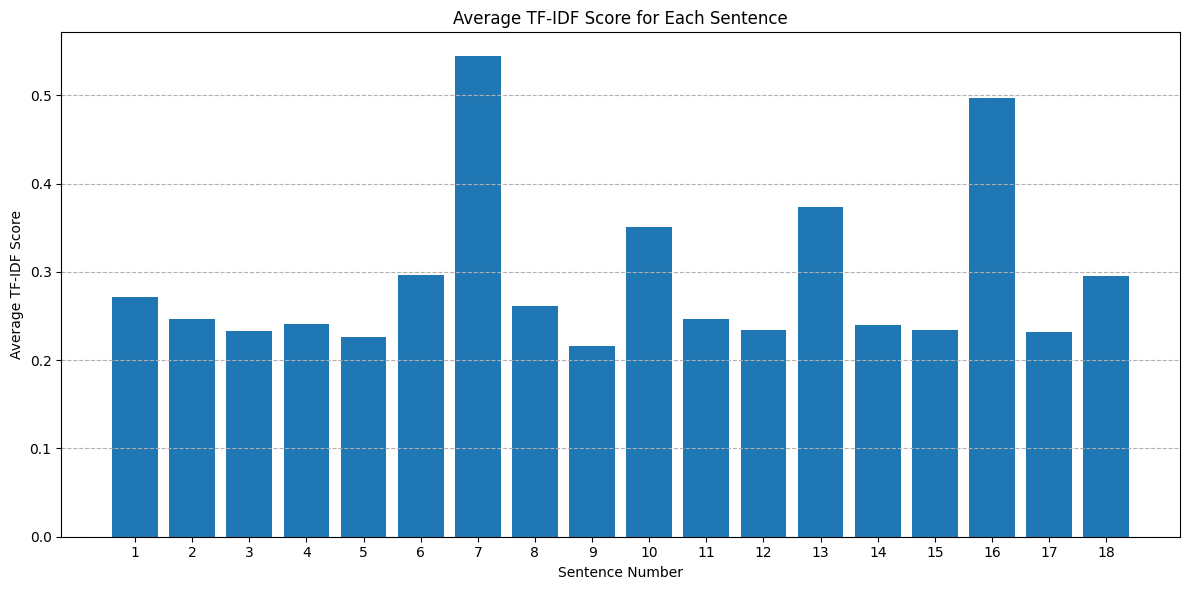


Explanation of the Histogram :
Imagine we've given each sentence in the news article a score based on the importance of the words it contains. This score is called the 'Average TF-IDF Score'.

The histogram above is like a bar chart that shows this score for each sentence:
- The horizontal line (Sentence Number):** Each number on this line represents a different sentence in the article, starting from the first sentence (1) to the last.
- The vertical bar for each sentence:** The height of each bar shows the 'Average TF-IDF Score' for that particular sentence.

 What does the height of the bar tell us?
- Taller bar: A taller bar means the sentence contains words that are considered more important and unique within the entire article. These sentences likely carry more key information.
- Shorter bar: A shorter bar means the sentence contains words that are either less important or more common throughout the article. These sentences might be supporting details or less central to the main 

In [23]:
# Visualize the average TF-IDF scores as a histogram
plt.figure(figsize=(12, 6))
plt.bar(range(1, len(sent_scores) + 1), sent_scores)
plt.xlabel("Sentence Number")
plt.ylabel("Average TF-IDF Score")
plt.title("Average TF-IDF Score for Each Sentence")
plt.xticks(range(1, len(sent_scores) + 1))
plt.grid(axis='y', linestyle='--')
plt.tight_layout()
plt.show()

# Explanation:
print("\nExplanation of the Histogram :")
print("Imagine we've given each sentence in the news article a score based on the importance of the words it contains. This score is called the 'Average TF-IDF Score'.")
print("\nThe histogram above is like a bar chart that shows this score for each sentence:")
print("- The horizontal line (Sentence Number):** Each number on this line represents a different sentence in the article, starting from the first sentence (1) to the last.")
print("- The vertical bar for each sentence:** The height of each bar shows the 'Average TF-IDF Score' for that particular sentence.")
print("\n What does the height of the bar tell us?")
print("- Taller bar: A taller bar means the sentence contains words that are considered more important and unique within the entire article. These sentences likely carry more key information.")
print("- Shorter bar: A shorter bar means the sentence contains words that are either less important or more common throughout the article. These sentences might be supporting details or less central to the main topic.")
print("\nSo, by looking at this chart, you can quickly get a sense of which sentences in the article are likely to be the most informative based on the words they use.")

# **(7) Generated Summary**
This step filters sentences based on whether their average TF-IDF score meets or exceeds the calculated threshold, compiling them into the final summary of the document.

In [24]:
# Final summary initialization
final_summ = ""

# Get summary sentences
print("\nSummary Sentences (above or equal to the threshold):")
for index, data in enumerate(sent_scores):
    if data >= threshold:
        final_summ = final_summ + " " + sentence[index]
        print(f"- {sentence[index]}")

print("\nFinal Summary:")
print(final_summ.strip())


Summary Sentences (above or equal to the threshold):
- "Mereka (Iran-red) tidak memiliki angkatan laut, tidak ada komunikasi, mereka tidak memiliki angkatan udara.
- Rudal-rudal mereka tinggal sedikit.
- "Jika Anda lihat, mereka tidak memiliki apa pun yang tersisa.
- "Kita sangat jauh lebih cepat dari jadwal," sebutnya.
- "Saya tidak punya pesan untuknya.
- Trump sebelumnya dilaporkan "tidak senang" dengan pemilihan Mojtaba sebagai pemimpin tertinggi baru Iran.

Final Summary:
"Mereka (Iran-red) tidak memiliki angkatan laut, tidak ada komunikasi, mereka tidak memiliki angkatan udara. Rudal-rudal mereka tinggal sedikit. "Jika Anda lihat, mereka tidak memiliki apa pun yang tersisa. "Kita sangat jauh lebih cepat dari jadwal," sebutnya. "Saya tidak punya pesan untuknya. Trump sebelumnya dilaporkan "tidak senang" dengan pemilihan Mojtaba sebagai pemimpin tertinggi baru Iran.
